# sc-GEM Analysis

In [1]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

embedding_dir = f'./embeddings/hgnn/sc_GEM'

DATA = 'sc_GEM'

def load_labels():
    cell_stage = np.array(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))[0]
    return cell_stage

def check_labels(cell_stage, cell_ids):
    for label, id in zip(cell_stage, cell_ids):
        if label not in id:
            print('Bad id', id, 'label', label)
            return False
    return True

In [3]:
cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
gene_embeddings = np.load(f'{embedding_dir}/mymodel_1.npy')
omics_embeddings = np.load(f'{embedding_dir}/mymodel_2.npy')

node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
cell_stage = np.array(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))[0]

metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [4]:
gene_embeddings.shape, cell_embeddings.shape

((61, 64), (224, 64))

In [5]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['BJ_2', 'BJ_44', 'BJ_11', 'BJ_14', 'BJ_19', 'BJ_41', 'BJ_22',
       'BJ_1', 'BJ_34', 'BJ_8', 'BJ_4', 'BJ_21', 'BJ_18', 'BJ_15',
       'BJ_24', 'BJ_31', 'BJ_35', 'BJ_13', 'BJ_12', 'BJ_40', 'BJ_17',
       'BJ_29', 'BJ_5', 'BJ_9', 'BJ_23', 'BJ_25', 'BJ_3', 'BJ_28',
       'BJ_37', 'BJ_32', 'BJ_26', 'BJ_27', 'BJ_7', 'BJ_46', 'BJ_43',
       'd8_8', 'd8_19', 'd8_34', 'd8_25', 'd8_16', 'd8_3', 'd8_13',
       'd8_22', 'd8_27', 'd8_26', 'd8_43', 'd8_40', 'd8_35', 'd8_5',
       'd8_38', 'd8_12', 'd8_14', 'd8_17', 'd8_44', 'd8_1', 'd8_29',
       'd8_37', 'd8_2', 'd8_21', 'd8_10', 'd8_30', 'd8_32', 'd8_7',
       'd8_18', 'd8_9', 'd8_39', 'd8_24', 'd8_33', 'd8_23', 'd8_11',
       'd8_46', 'd8_28', 'd8_45', 'd8_4', 'd8_41', 'd16T-_1', 'd16T-_4',
       'd16T-_8', 'd16T-_5', 'd16T-_7', 'd16T-_12', 'd16T-_6', 'd16T-_16',
       'd16T-_2', 'd16T-_9', 'd16T-_11', 'd16T-_15', 'd16T-_10',
       'd16T+_15', 'd16T+_11', 'd16T+_13', 'd16T+_9', 'd16T+_28',
       'd16T+_7', 'd16T+_2', 'd16T+_

In [6]:
check_labels(cell_stage, cell_names)

True

In [7]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

61

## Cell Embeddings

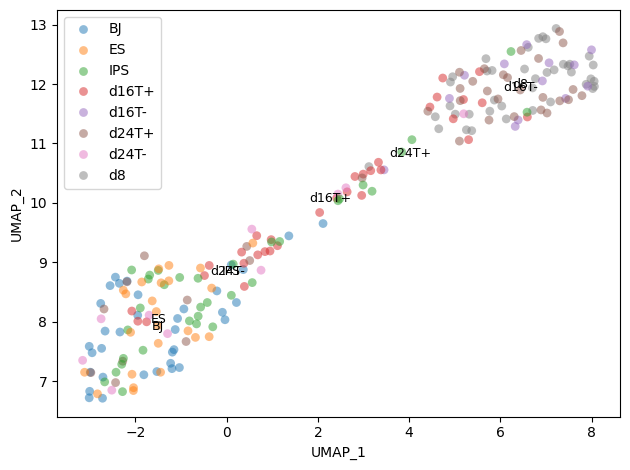

In [8]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage,
                hue_order=sorted(set(cell_stage)),
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")

# ---- 计算每个类的中心并标注 ----
df = pd.DataFrame({'UMAP_1': vec[:, 0], 'UMAP_2': vec[:, 1], 'label': cell_stage})
centroids = df.groupby('label')[['UMAP_1', 'UMAP_2']].mean()

for label, row in centroids.iterrows():
    plt.text(row['UMAP_1'], row['UMAP_2'], str(label),
             fontsize=9, ha='center', va='center',)
plt.tight_layout()

ES, IPS, d24T+ are in one group.

Others are in the other group.

## Heatmaps of gene embeddings

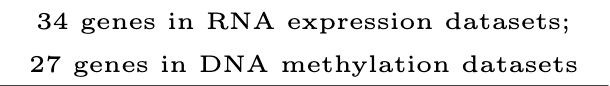

In [9]:
gene_embeddings.shape, len(gene_names)

((61, 64), 61)

In [10]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,-0.128187,0.306387,1.068351,0.434159,0.127632,-15.779681,0.294272,0.578397,0.238607,-0.165716,...,0.806692,0.029875,-0.195753,0.059958,0.397079,0.933694,0.444629,-0.056485,-0.013508,0.268985
1,-0.361849,-0.108988,0.917243,-0.565270,0.364074,-13.650734,0.867272,-0.853346,0.912099,0.621531,...,-1.451976,-0.437724,-0.268839,-0.201241,0.027644,-0.885343,0.917446,0.456546,0.339479,0.093482
2,1.225986,1.635414,0.856279,0.011584,0.357807,-13.234356,0.329493,1.520497,1.197799,-0.740448,...,0.958978,1.594162,-0.433316,0.587041,0.273102,-1.640539,0.158037,-0.248267,0.394716,0.529275
3,0.129616,-0.124483,-0.635575,-0.716617,0.430114,-14.077868,0.152628,-1.242163,-0.499183,-1.255198,...,0.622869,1.652344,-0.509202,0.284503,-0.287151,0.520351,0.534544,0.565000,-0.127115,0.820699
4,-0.337872,-0.315105,-0.751420,-0.623632,-0.229881,13.566216,-0.284535,0.493979,-0.463752,1.426698,...,-0.807140,-1.819578,0.393360,-0.679966,-0.743791,0.327332,-0.790886,-0.373549,-0.152691,-1.215210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-0.771326,0.244649,1.390770,0.792773,1.949053,-6.667336,0.308913,0.100764,0.870404,-0.659417,...,-0.115384,1.045961,-0.187214,0.631156,0.540714,-0.649670,-0.315367,-0.177874,-0.177653,0.727760
60,0.300866,-0.725179,-0.686504,-0.709783,-1.041094,14.019003,-0.011820,0.631494,-0.965819,0.455914,...,-0.114047,-0.206788,0.888212,-0.033527,-0.235775,0.956123,-0.146165,-0.044212,0.158454,-0.268088
61,0.154947,0.576588,0.013077,-0.340577,1.263249,-14.316670,-0.174612,0.322045,0.107531,-0.615538,...,-0.048165,0.753759,-0.189819,-0.080644,0.202730,-0.249353,0.293994,-0.156790,0.284428,0.706987
62,-0.592908,-1.492711,-1.831458,-1.553628,-0.639219,4.261560,0.467061,1.620600,-1.382520,0.955258,...,-0.251237,-0.580293,1.179693,-0.790374,0.019722,2.399357,-0.411564,-0.517831,0.466375,-1.202008


In [11]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [12]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

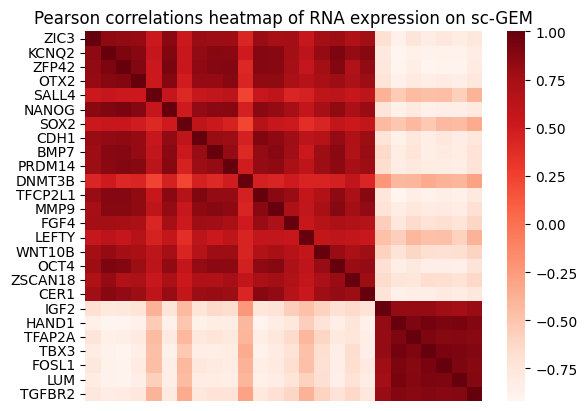

In [13]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Reds', yticklabels=EXPR_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [14]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

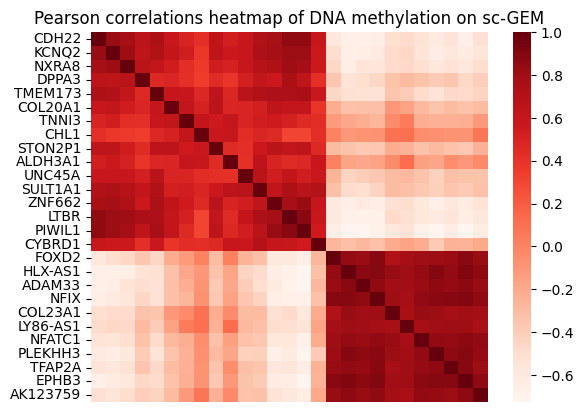

In [15]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [16]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [17]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [18]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)


In [19]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

1.0

In [20]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [21]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [22]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

### Somatic projection

In [23]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,variable,value
0,BJ,TFAP2A,6.214193
1,BJ,TFAP2A,7.684377
2,BJ,TFAP2A,7.037281
3,BJ,TFAP2A,6.588261
4,BJ,TFAP2A,7.096816
...,...,...,...
1115,ES,TGFBR2,7.053216
1116,ES,TGFBR2,6.878524
1117,ES,TGFBR2,7.366049
1118,ES,TGFBR2,6.584600


Text(0, 0.5, 'Projection value')

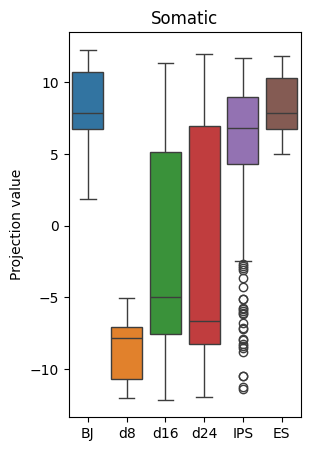

In [24]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [25]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,variable,value
0,BJ,ZIC3,-4.509880
1,BJ,ZIC3,-5.894240
2,BJ,ZIC3,-5.328546
3,BJ,ZIC3,-5.558081
4,BJ,ZIC3,-5.417341
...,...,...,...
4251,ES,CER1,-7.255777
4252,ES,CER1,-7.690960
4253,ES,CER1,-8.323659
4254,ES,CER1,-7.074008


Text(0, 0.5, 'Projection value')

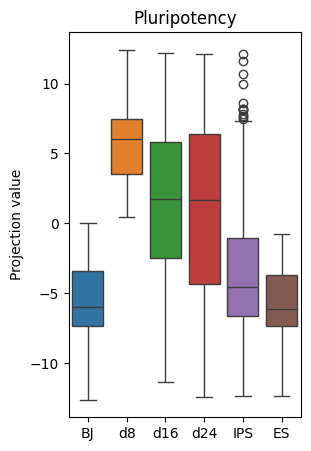

In [26]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [27]:
cell_stage_unique = sorted(set(cell_stage))
num_clusters = len(cell_stage_unique)
# Convert str to label id.
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage_unique)}
cell_stage_label = np.array([cell_stage_ids[y] for y in
                             cell_stage])

print(cell_stage_unique)
print('num_clusters', num_clusters)
print(cell_stage_ids)
print(np.min(cell_stage_label), np.max(cell_stage_label))

['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8']
num_clusters 8
{'BJ': 0, 'ES': 1, 'IPS': 2, 'd16T+': 3, 'd16T-': 4, 'd24T+': 5, 'd24T-': 6, 'd8': 7}
0 7


In [28]:
from scoit.cell_analysis import cluster_evaluate

cluster_evaluate(cell_embeddings, cell_stage)

{'NMI': 0.30073985713440265,
 'ARI': 0.1306312420570921,
 'FMI': 0.26633860689591055}

### Baselines

t-SNE, PCA, UMAP.

In [29]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [30]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))

In [31]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.017027616500854492
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

In [32]:
assert (create.df.index == cell_names).all().all()


In [33]:
features = create.df.values
features.shape

(224, 61)

In [34]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
    'Ours': None, # Placeholder
}

def run_baselines(features, cell_embeddings, dims=3):
    records = []
    k = num_clusters
    for name, method in baselines.items():
        print(name)
        if method is None:
            x = UMAP(n_components=dims).fit_transform(cell_embeddings)
        else:
            x = method(n_components=dims).fit_transform(features)

        x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
        x = x / x_norm
        _, c, _ = k_means(x, k)
        c_aligned = align_cluster(c, cell_stage_label)
        kmeans_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in kmeans_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='kmeans'))

        adj = knn_adj_matrix(x)
        c = RunLeiden(adj)
        c_aligned = align_cluster(c, cell_stage_label)
        leiden_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in leiden_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='leiden'))

    return pd.DataFrame.from_records(records)


### K-means performance

In [35]:
df_cluster = run_baselines(features, cell_embeddings, dims=3)

TSNE


NameError: name 'k_means' is not defined

Text(0, 0.5, '')

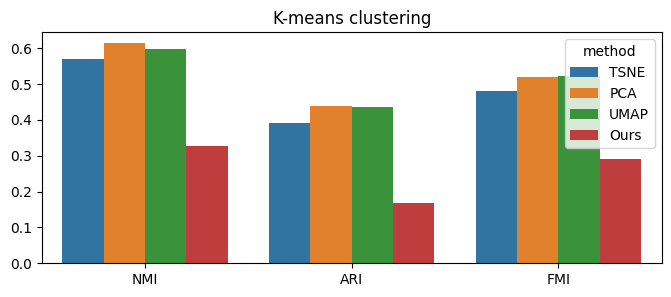

In [ ]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'kmeans'], x='metric', y='value', hue='method')
plt.title('K-means clustering')
plt.xlabel('')
plt.ylabel('')

### Leiden community detection

Text(0, 0.5, '')

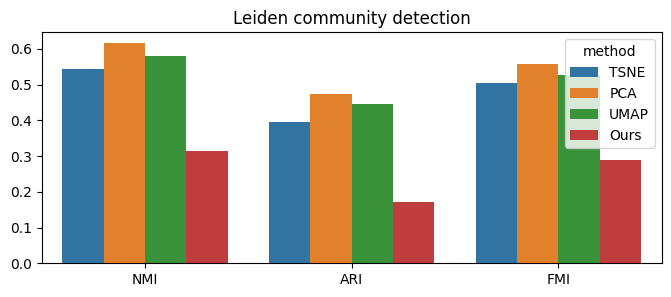

In [ ]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'leiden'], x='metric', y='value', hue='method')
plt.title('Leiden community detection')
plt.xlabel('')
plt.ylabel('')